# Fase 16c: Deep learning para la clasificacion de direccion

## Objetivo y posicion dentro del estudio

Esta fase extiende la clasificacion binaria de la fase 16 sin sustituirla.
La regresion Ridge, el clasificador de referencia y sus resultados permanecen
intactos. Aqui se pregunta si una red neuronal puede aprender una representacion
adicional de las mismas variables sin memorizar el ruido.

Se comparan dos arquitecturas:

1. MLP tabular: recibe las 83 features disponibles en el dia t.
2. GRU temporal: recibe una ventana causal de 21 dias terminada en t.

La etiqueta es:

    dir_1(t) = 1 si gold_spot(t+1) > gold_spot(t), 0 en otro caso.

La seleccion se hace con validation (2020-2022). El test (2023-2025) permanece
bloqueado y se consulta solo despues de congelar la arquitectura y los
hiperparametros. Se usa AUC como metrica primaria porque el accuracy depende
del umbral y del balance de clases.

## Hipotesis

- H1: una MLP regularizada puede capturar interacciones no lineales que un
  modelo lineal no captura.
- H2: una GRU puede aprovechar el orden temporal de una ventana de observacion.
- H3: la mejora solo es valida si se mantiene fuera de muestra, entre semillas
  y frente al RandomForest regularizado de la fase 17c.

## Control contra overfitting

- Preprocesador ajustado solo con train.
- Ventanas causales sin observaciones posteriores a t.
- Early stopping basado exclusivamente en AUC de validation.
- Weight decay, dropout y clipping de gradiente.
- Comparacion train, validation y test.
- Registro del dispositivo: CUDA cuando esta disponible, CPU como fallback.

> **Aviso de auditoria:** las cifras y salidas mostradas en este notebook corresponden a una ejecucion anterior a las correcciones metodologicas. Es necesario reejecutar el pipeline completo antes de usar o comunicar sus resultados.


Configuracion del notebook y deteccion de hardware.

Este bloque hace explicito el dispositivo que se empleara. No se asume que
una GPU exista: en una instalacion sin CUDA el mismo experimento funciona en
CPU. La ejecucion conserva una ficha del entorno para reproducibilidad.


In [1]:
import sys
from pathlib import Path


def find_root() -> Path:
    p = Path.cwd().resolve()
    for candidate in (p, *p.parents):
        if (candidate / "configs" / "config.yaml").is_file():
            return candidate
    raise FileNotFoundError(
        "No se encontro configs/config.yaml desde el directorio de trabajo. "
        "Abra Jupyter dentro del repositorio."
    )


ROOT = find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import get_config
from src.models.deep_learning import device_report, get_device, set_torch_seed
from src.utils import path_from_root, set_publication_style

cfg = get_config()
dl_cfg = cfg.get("deep_learning", {})
seed = int(dl_cfg.get("seed", cfg.get("project", {}).get("seed", 42)))
lookback = int(dl_cfg.get("lookback", 21))
set_publication_style()
set_torch_seed(seed)
device = get_device(prefer_gpu=dl_cfg.get("device", "auto") != "cpu")
print(device_report(device))


{'device': 'cuda', 'cuda_available': True, 'cuda_version': '12.8', 'device_count': 1, 'device_name': 'NVIDIA GeForce RTX 3050 Ti Laptop GPU', 'torch_version': '2.11.0+cu128'}


Carga de datos y preparacion del target.

Se reutilizan exactamente los features de la version estable y el split
temporal ya congelado. No se recalculan estadisticas con validation o test.
La lista de features se carga desde el artefacto oficial para garantizar que
el experimento DL recibe las mismas entradas que el modelo clasico.


In [2]:
import json
import numpy as np
import pandas as pd

from src.data.split import drop_warmup, temporal_split, purge_label_overlap
from src.models.classifier import make_direction_targets

features_all = pd.read_parquet(path_from_root("data/processed/features.parquet"))
features_df = drop_warmup(features_all, warmup=260)
parts = temporal_split(features_df, cfg)
parts = purge_label_overlap(parts, cfg=cfg)
with open(path_from_root("models", "feature_list.json"), encoding="utf-8") as f:
    feature_cols = json.load(f)

direction_df = make_direction_targets(features_all, [1])
train = parts["train"].merge(direction_df[["date", "dir_1"]], on="date", how="left")
val = parts["val"].merge(direction_df[["date", "dir_1"]], on="date", how="left")
test = parts["test"].merge(direction_df[["date", "dir_1"]], on="date", how="left")

print("features:", len(feature_cols))
print("train/val/test:", len(train), len(val), len(test))
print("positive rate:", train["dir_1"].mean(), val["dir_1"].mean(), test["dir_1"].mean())


features: 83
train/val/test: 4957 783 684
positive rate: 0.5204760944119428 0.5402298850574713 0.5365497076023392


Construccion de matrices tabulares y secuencias temporales.

Para la MLP se usa una fila por fecha. Para la GRU, la funcion make_sequences
construye una ventana de 21 observaciones que termina exactamente en t. La
etiqueta corresponde a t+1, pero nunca se incluye t+1 en la ventana. El
preprocesador se ajusta exclusivamente con train y se aplica mediante
transform a validation y test.


In [3]:
from src.models.deep_learning import make_sequences
from src.models.pipeline import fit_preprocessor

# Matrices tabulares
X_train_raw = train[feature_cols].to_numpy(np.float32)
y_train = train["dir_1"].to_numpy(np.float32)
X_val_raw = val[feature_cols].to_numpy(np.float32)
y_val = val["dir_1"].to_numpy(np.float32)
X_test_raw = test[feature_cols].to_numpy(np.float32)
y_test = test["dir_1"].to_numpy(np.float32)

preprocessor = fit_preprocessor(X_train_raw.astype(np.float64))
X_train = preprocessor.transform(X_train_raw).astype(np.float32)
X_val = preprocessor.transform(X_val_raw).astype(np.float32)
X_test = preprocessor.transform(X_test_raw).astype(np.float32)

# Secuencias causales: cada ventana termina en su fecha objetivo.
sequence_df = features_all.merge(direction_df[["date", "dir_1"]], on="date", how="left")
sequence_df = sequence_df.dropna(subset=[*feature_cols, "dir_1"]).reset_index(drop=True)
X_seq_train, y_seq_train, dates_seq_train = make_sequences(
    sequence_df, feature_cols, "dir_1", train["date"], lookback=lookback
)
X_seq_val, y_seq_val, dates_seq_val = make_sequences(
    sequence_df, feature_cols, "dir_1", val["date"], lookback=lookback
)
X_seq_test, y_seq_test, dates_seq_test = make_sequences(
    sequence_df, feature_cols, "dir_1", test["date"], lookback=lookback
)

# Escalado causal para la GRU: se transforma cada paso con estadisticas de train.
def transform_sequences(x):
    shape = x.shape
    return preprocessor.transform(x.reshape(-1, shape[-1])).reshape(shape).astype(np.float32)

X_seq_train = transform_sequences(X_seq_train)
X_seq_val = transform_sequences(X_seq_val)
X_seq_test = transform_sequences(X_seq_test)

assert train["date"].reset_index(drop=True).equals(dates_seq_train.reset_index(drop=True))
assert val["date"].reset_index(drop=True).equals(dates_seq_val.reset_index(drop=True))
assert test["date"].reset_index(drop=True).equals(dates_seq_test.reset_index(drop=True))
for array in [X_train, X_val, X_test, X_seq_train, X_seq_val, X_seq_test]:
    assert np.isfinite(array).all()

print("MLP shapes:", X_train.shape, X_val.shape, X_test.shape)
print("GRU shapes:", X_seq_train.shape, X_seq_val.shape, X_seq_test.shape)


MLP shapes: (4957, 83) (783, 83) (684, 83)
GRU shapes: (4957, 21, 83) (783, 21, 83) (684, 21, 83)


Entrenamiento de la MLP tabular con early stopping.

La MLP tiene dos capas ocultas, dropout y regularizacion L2 mediante AdamW.
El numero de epocas no se decide mirando test: early stopping guarda el estado
con mejor AUC en validation. Se informa de la epoca elegida y del dispositivo.


In [4]:
from src.models.deep_learning import TabularMLP, train_binary_model

mlp_cfg = dl_cfg.get("mlp", {})
set_torch_seed(seed)
mlp = TabularMLP(
    n_features=X_train.shape[1],
    hidden=tuple(int(v) for v in mlp_cfg.get("hidden_layers", [128, 64])),
    dropout=float(mlp_cfg.get("dropout", 0.30)),
)
mlp_result = train_binary_model(
    mlp, X_train, y_train, X_val, y_val, device=device,
    epochs=int(dl_cfg.get("epochs", 120)),
    batch_size=int(dl_cfg.get("batch_size", 128)),
    learning_rate=float(mlp_cfg.get("learning_rate", 1e-3)),
    weight_decay=float(mlp_cfg.get("weight_decay", 1e-3)),
    patience=int(dl_cfg.get("patience", 20)),
    seed=seed,
)
print("MLP device:", mlp_result.device)
print("MLP best epoch:", mlp_result.best_epoch)
print("MLP best validation AUC:", mlp_result.best_val_auc)


MLP device: cuda
MLP best epoch: 8
MLP best validation AUC: 0.549619122668768


Entrenamiento de la GRU temporal con early stopping.

La GRU procesa la secuencia en orden temporal y solo la representacion del
ultimo paso se conecta con la salida. La arquitectura es deliberadamente
pequena: con aproximadamente 5.700 observaciones no seria responsable usar
una red profunda grande. El control principal vuelve a ser validation AUC.


In [5]:
from src.models.deep_learning import GRUDirectionModel

gru_cfg = dl_cfg.get("gru", {})
set_torch_seed(seed)
gru = GRUDirectionModel(
    n_features=X_seq_train.shape[2],
    hidden_size=int(gru_cfg.get("hidden_size", 64)),
    dropout=float(gru_cfg.get("dropout", 0.25)),
)
gru_result = train_binary_model(
    gru, X_seq_train, y_seq_train, X_seq_val, y_seq_val, device=device,
    epochs=int(dl_cfg.get("epochs", 120)),
    batch_size=int(dl_cfg.get("batch_size", 128)),
    learning_rate=float(gru_cfg.get("learning_rate", 8e-4)),
    weight_decay=float(gru_cfg.get("weight_decay", 1e-3)),
    patience=int(dl_cfg.get("patience", 20)),
    seed=seed,
)
print("GRU device:", gru_result.device)
print("GRU best epoch:", gru_result.best_epoch)
print("GRU best validation AUC:", gru_result.best_val_auc)


GRU device: cuda
GRU best epoch: 2
GRU best validation AUC: 0.5434003152088258


Comparacion de curvas de entrenamiento.

Las curvas muestran la perdida de entrenamiento y el AUC de validation por
epoca. Una diferencia que crece sin mejora en validation seria sobreajuste.
El early stopping congela el mejor punto antes de que el modelo memorice.


[fig] C:\Users\sgml1\Desktop\gold-price-prediction\reports\figures\deep_learning_training_curves.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction/reports/figures/deep_learning_training_curves.png')

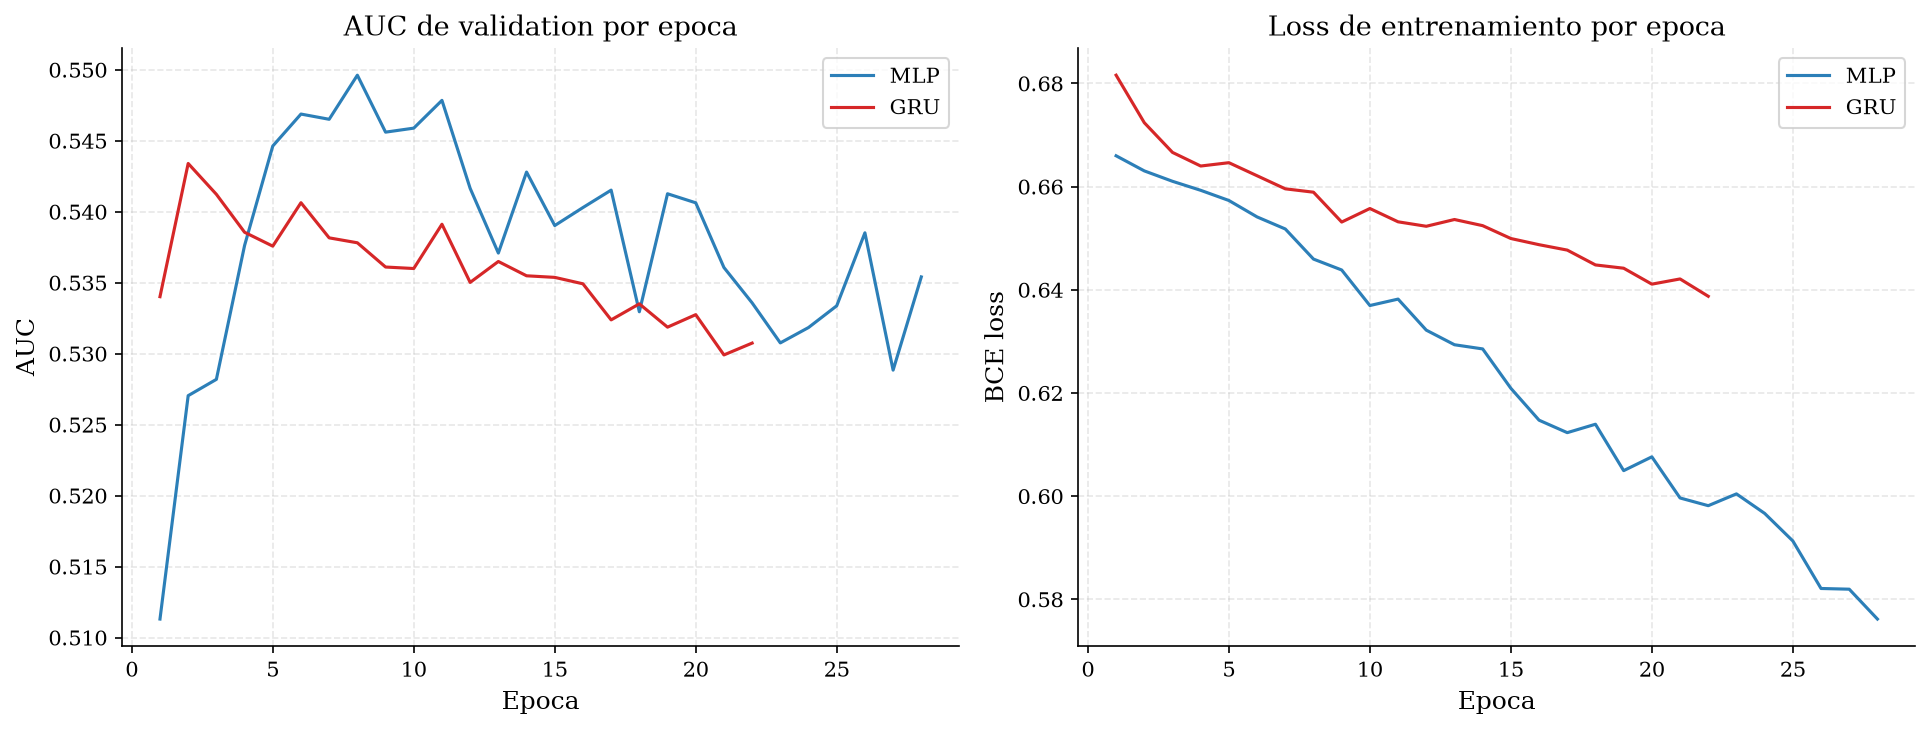

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for result, label, color in [(mlp_result, "MLP", "#2c7fb8"), (gru_result, "GRU", "#d62728")]:
    hist = pd.DataFrame(result.history)
    axes[0].plot(hist["epoch"], hist["val_auc"], label=label, color=color)
    axes[1].plot(hist["epoch"], hist["train_loss"], label=label, color=color)
axes[0].set_title("AUC de validation por epoca")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("AUC")
axes[1].set_title("Loss de entrenamiento por epoca")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("BCE loss")
for ax in axes:
    ax.legend()
fig.tight_layout()
from src.utils import save_fig
save_fig(fig, "deep_learning_training_curves.png")


Evaluacion bloqueada en test y comparacion con el clasificador clasico.

Se calculan AUC, PR-AUC, accuracy, F1 y Brier. La eleccion final se basa en
validation, no en el resultado de test. Test se muestra ahora para la
comparacion final congelada.


In [7]:
from src.evaluation.metrics import classification_metrics
from src.models.deep_learning import predict_proba

mlp_test_prob = predict_proba(mlp_result.model, X_test, device=device)
gru_test_prob = predict_proba(gru_result.model, X_seq_test, device=device)

mlp_metrics = classification_metrics(y_test, mlp_test_prob)
gru_metrics = classification_metrics(y_seq_test, gru_test_prob)

comparison = pd.DataFrame([
    {"model": "MLP", **mlp_metrics},
    {"model": "GRU", **gru_metrics},
])
print(comparison[["model", "auc", "pr_auc", "accuracy", "f1", "brier"]].round(4).to_string(index=False))
print()
print("Dispositivo MLP:", mlp_result.device)
print("Dispositivo GRU:", gru_result.device)


model    auc  pr_auc  accuracy     f1  brier
  MLP 0.5336  0.5571    0.4883 0.2915 0.2594
  GRU 0.5104  0.5502    0.4649 0.0054 0.2736

Dispositivo MLP: cuda
Dispositivo GRU: cuda


Analisis de overfitting, estabilidad y decision.

Se compara train/validation/test y se registra el modelo DL que gana en
validation. Si DL no supera al RandomForest regularizado de fase 17c, se
conserva como experimento reproducible y no se reemplaza el modelo operativo.
La conclusion debe distinguir capacidad expresiva de generalizacion real.


In [8]:
from src.models.deep_learning import device_report
from src.utils import save_json

# Metricas train de los modelos DL para cuantificar el gap.
mlp_train_prob = predict_proba(mlp_result.model, X_train, device=device)
gru_train_prob = predict_proba(gru_result.model, X_seq_train, device=device)
mlp_train_metrics = classification_metrics(y_train, mlp_train_prob)
gru_train_metrics = classification_metrics(y_seq_train, gru_train_prob)

rows = [
    {"model": "MLP", "train_auc": mlp_train_metrics["auc"],
     "val_auc": mlp_result.best_val_auc, "test_auc": mlp_metrics["auc"],
     "device": mlp_result.device},
    {"model": "GRU", "train_auc": gru_train_metrics["auc"],
     "val_auc": gru_result.best_val_auc, "test_auc": gru_metrics["auc"],
     "device": gru_result.device},
]
summary = pd.DataFrame(rows)
print(summary.round(4).to_string(index=False))
best_name = summary.sort_values("val_auc", ascending=False).iloc[0]["model"]
print()
print("Modelo neuronal ganador por validation:", best_name)
print("Decision: el ganador solo podria reemplazar al clasificador tras superar tambien el walk-forward.")

save_json({"device": device_report(device), "comparison": rows,
           "selected_by_validation": best_name}, "deep_learning_results.json")


model  train_auc  val_auc  test_auc device
  MLP     0.6488   0.5496    0.5336   cuda
  GRU     0.5690   0.5434    0.5104   cuda

Modelo neuronal ganador por validation: MLP
Decision: el ganador solo podria reemplazar al clasificador tras superar tambien el walk-forward.
[json] C:\Users\sgml1\Desktop\gold-price-prediction\reports\deep_learning_results.json


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction/reports/deep_learning_results.json')

Persistencia de pesos y configuracion.

Se guardan los pesos de MLP y GRU, el preprocesador, la lista de features y
los metadatos del dispositivo. Los archivos .pt estan ignorados por git para
no introducir binarios grandes, pero se pueden regenerar ejecutando este
notebook.


In [9]:
from src.models.deep_learning import save_deep_artifacts

metadata_common = {
    "horizon": 1,
    "feature_count": len(feature_cols),
    "lookback": lookback,
    "seed": seed,
    "device": device_report(device),
    "selected_by": "validation_auc",
}
save_deep_artifacts(mlp_result.model, preprocessor, feature_cols, "direction_mlp", {
    **metadata_common, "architecture": "TabularMLP", "best_epoch": mlp_result.best_epoch
})
save_deep_artifacts(gru_result.model, preprocessor, feature_cols, "direction_gru", {
    **metadata_common, "architecture": "GRUDirectionModel", "best_epoch": gru_result.best_epoch
})
print("Artefactos neuronales guardados en models/ y resultados en reports/deep_learning_results.json")


Artefactos neuronales guardados en models/ y resultados en reports/deep_learning_results.json
